In [14]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# Closure Feed Analysis

In [12]:
alerts_path = Path.cwd() / 'Road_Closure_Feeds'

closures_df = pd.concat(
    [pd.read_csv(f) for f in alerts_path.iterdir() if f.suffix.lower() == ".csv"],
    ignore_index=True
)
closures_df['extraction_date'] = pd.to_datetime(closures_df['extraction_date'])

In [3]:
closures_df.head()

,extraction_date,is_start_date_verified,is_end_date_verified,is_start_position_verified,is_end_position_verified,types_of_incident,start_date,end_date,location_method,vehicle_impact,...,core_details.event_type,core_details.road_names,core_details.direction,core_details.description,types_of_work,data_source_id,organization_name,update_date,contact_name,contact_email
0,3/13/2026,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,incident,"['North Entrance Road', 'West Rim Drive', 'Eas...",eastbound,Seasonal closure of North Entrance Road and Ri...,NaN,NaN,Crater Lake National Park,2024-02-01T01:07:37.430224Z,Crater Lake National Park,CRLA_Superintendent@nps.gov
1,3/13/2026,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,incident,"['North Entrance Road', 'West Rim Drive', 'Eas...",northbound,Seasonal closure of North Entrance Road and Ri...,NaN,NaN,Crater Lake National Park,2024-02-01T01:07:37.430224Z,Crater Lake National Park,CRLA_Superintendent@nps.gov
2,3/13/2026,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,incident,"['North Entrance Road', 'West Rim Drive', 'Eas...",northbound,Seasonal closure of North Entrance Road and Ri...,NaN,NaN,Crater Lake National Park,2024-02-01T01:07:37.430224Z,Crater Lake National Park,CRLA_Superintendent@nps.gov
3,3/13/2026,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,incident,"['North Entrance Road', 'West Rim Drive', 'Eas...",southbound,Seasonal closure of North Entrance Road and Ri...,NaN,NaN,Crater Lake National Park,2024-02-01T01:07:37.430224Z,Crater Lake National Park,CRLA_Superintendent@nps.gov
4,3/13/2026,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,incident,"['North Entrance Road', 'West Rim Drive', 'Eas...",northbound,Seasonal closure of North Entrance Road and Ri...,NaN,NaN,Crater Lake National Park,2024-02-01T01:07:37.430224Z,Crater Lake National Park,CRLA_Superintendent@nps.gov


## Number of Closures Over Time

In [13]:
closure_count_by_park = pd.pivot_table(
    closures_df,
    values='core_details.event_type',
    index = 'organization_name',
    columns='extraction_date',
    aggfunc='count'
)
closure_count_by_park = closure_count_by_park.fillna(0).astype(int)
closure_count_by_park

extraction_date,2026-03-13,2026-03-14,2026-03-15,2026-03-16,2026-03-17,2026-03-18,2026-03-19,2026-03-20
organization_name,,,,,,,,
Black Canyon of the Gunnison National Park,8,8,8,0,8,8,8,8
Blue Ridge Parkway,20,20,20,20,70,70,70,72
Buffalo National River,2,2,2,2,2,2,2,2
Crater Lake National Park,10,10,10,10,10,10,10,10
Curecanti National Recreation Area,2,2,2,0,2,2,2,2
Delaware Water Gap,18,18,18,0,18,18,18,18
Fort Dupont Park,0,0,0,0,20,0,0,0
Golden Gate National Recreation Area,2,2,2,0,2,2,0,0
Grand Canyon National Park,6,6,6,6,6,6,6,6


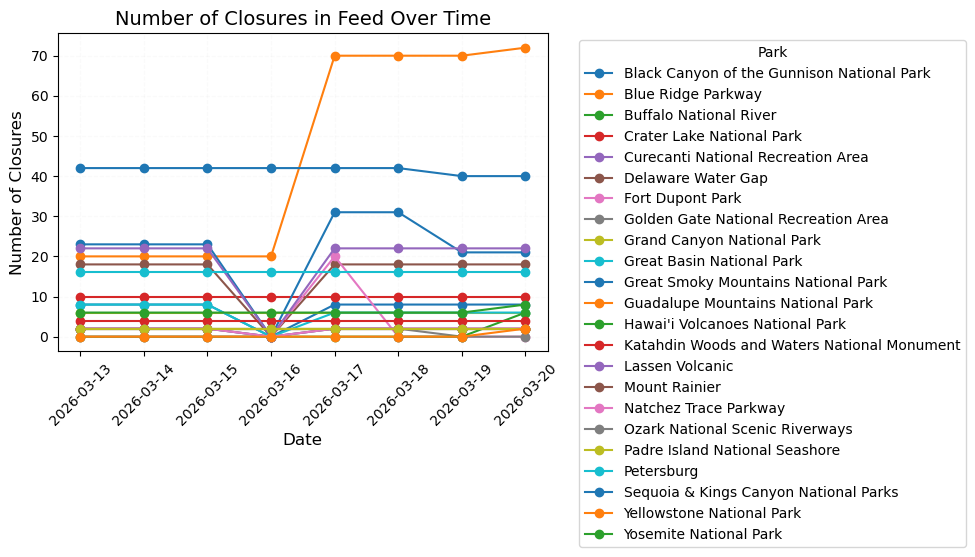

In [19]:
df_plot = closure_count_by_park.T
plt.figure(figsize=(10, 5))

for column in df_plot.columns:
    plt.plot(df_plot.index, df_plot[column], marker='o', label=column)

plt.title("Number of Closures in Feed Over Time", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.xticks(rotation=45)
plt.ylabel("Number of Closures", fontsize=12)
plt.legend(title="Park", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=.06)
    
plt.tight_layout()

# Alerts Feed Analysis

In [6]:
alerts_path = Path.cwd() / 'Alerts_Feeds'

alerts_df = pd.concat(
    [pd.read_csv(f) for f in alerts_path.iterdir() if f.suffix.lower() == ".csv"],
    ignore_index=True
)

## Number of Alerts Over Time

In [7]:
alerts_count_by_park = pd.pivot_table(
    alerts_df,
    values='id',
    index = 'parkCode',
    columns='extraction_date',
    aggfunc='count'
)
alerts_count_by_park = alerts_count_by_park.fillna(0).astype(int)
alerts_count_by_park

extraction_date,2026-03-13,2026-03-14,2026-03-15,2026-03-16,2026-03-17,2026-03-18,2026-03-19,2026-03-20
parkCode,,,,,,,,
abli,0,0,0,1,1,1,1,0
acad,1,1,1,1,2,2,3,3
adam,3,3,3,3,3,3,3,3
afbg,1,1,1,1,1,1,1,1
agfo,2,2,2,2,2,2,2,2
...,...,...,...,...,...,...,...,...
yell,4,4,4,3,4,4,4,4
york,1,1,1,1,1,1,1,1
yose,1,1,1,1,1,1,1,1
